In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../input/titanic/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
687/891
#lots of null rows

0.7710437710437711

In [9]:
df.drop("Cabin", axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
df.shape

(891, 11)

In [11]:
177/891
#less than 20%

0.19865319865319866

<AxesSubplot:xlabel='Survived', ylabel='Age'>

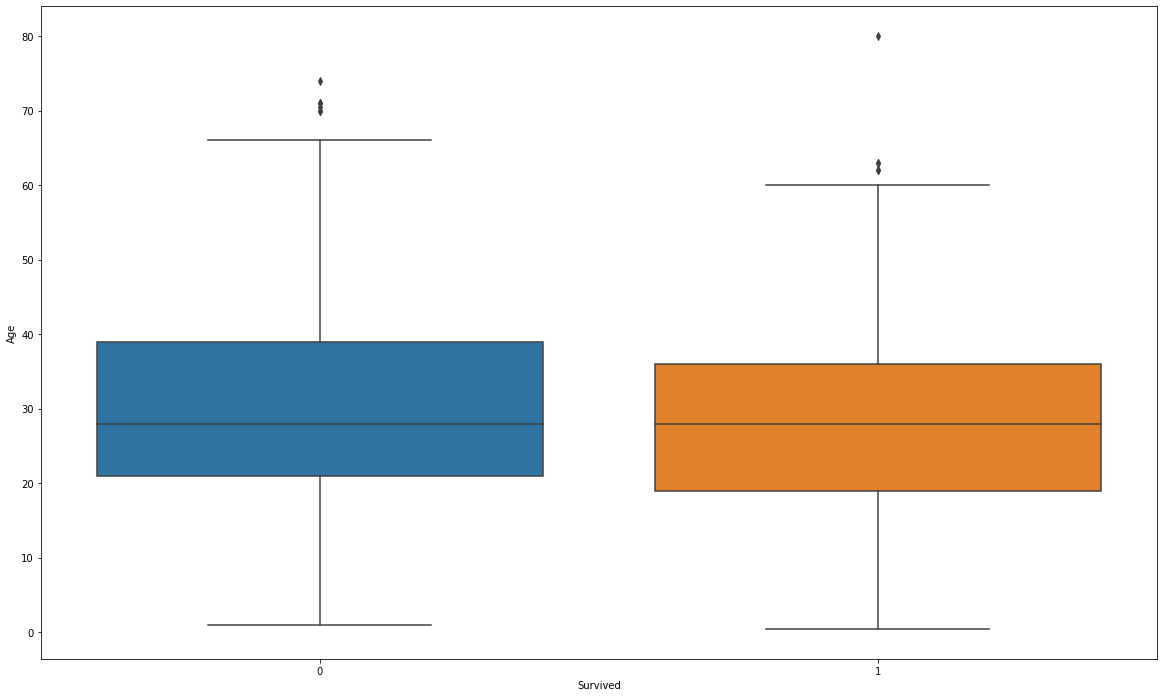

In [12]:
#age seems to be an important variable here to be saved
plt.figure(figsize=(20, 12))
sns.boxplot(x = 'Survived', y = 'Age', data = df)

In [13]:
df.Age.mean()

29.69911764705882

In [14]:
df.Age.median()

28.0

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [16]:
df.Age.isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Age, Length: 891, dtype: bool

In [17]:
df.Age.isnull().sum()

0

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [19]:
#Drop the rows of embarked having null values
df1 = df[~df.Embarked.isnull()]

In [20]:
df1.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [21]:
dummy1 = pd.get_dummies(df1['Sex'], drop_first = True)
dummy1.head()

,male
0,1
1,0
2,0
3,0
4,1


In [22]:
df1 = pd.concat([df1, dummy1], axis = 1)
df1.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [23]:
df1.drop(['Sex'], axis = 1, inplace = True)
df1.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Embarked,male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,S,1


In [24]:
# we will also drop name for now and deal with only numbers leading to the survival 
#(I am sure they wouldn't have asked for names in the time of their emergency)

df1.drop(['Name'], axis = 1, inplace = True)
df1.head()



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Embarked,male
0,1,0,3,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,35.0,1,0,113803,53.1000,S,0
4,5,0,3,35.0,0,0,373450,8.0500,S,1


In [25]:
#proabably even ticket's contents are capture by its fare we gon drop even that\
df1. drop(["Ticket"], axis = 1, inplace = True)
df1.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male
0,1,0,3,22.0,1,0,7.2500,S,1
1,2,1,1,38.0,1,0,71.2833,C,0
2,3,1,3,26.0,0,0,7.9250,S,0
3,4,1,1,35.0,1,0,53.1000,S,0
4,5,0,3,35.0,0,0,8.0500,S,1


In [26]:
dummy2 = pd.get_dummies(df1['Embarked'], drop_first = True)
dummy2.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [27]:
df1 = pd.concat([df1, dummy2], axis = 1)
df1.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,1,0,3,22.0,1,0,7.2500,S,1,0,1
1,2,1,1,38.0,1,0,71.2833,C,0,0,0
2,3,1,3,26.0,0,0,7.9250,S,0,0,1
3,4,1,1,35.0,1,0,53.1000,S,0,0,1
4,5,0,3,35.0,0,0,8.0500,S,1,0,1


In [28]:
df1.drop(['Embarked'], axis = 1, inplace = True)
df1.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


In [29]:
df1.drop(["PassengerId"], axis = 1, inplace = True)
df1.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [30]:
dummy3 = pd.get_dummies(df1['Pclass'], drop_first = True)
dummy3.rename(columns = {2:'Pclass_2', 3:'Pclass_3'}, inplace = True)
dummy3.head()

,Pclass_2,Pclass_3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1


In [31]:
df1 = pd.concat([df1, dummy3], axis = 1)

df1.drop(["Pclass"], axis = 1, inplace = True)

df1.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,1,0,1,0,1
1,1,38.0,1,0,71.2833,0,0,0,0,0
2,1,26.0,0,0,7.9250,0,0,1,0,1
3,1,35.0,1,0,53.1000,0,0,1,0,0
4,0,35.0,0,0,8.0500,1,0,1,0,1


In [32]:
from sklearn.model_selection import train_test_split


In [33]:
X = df1.drop(['Survived'], axis=1)

X.head()

,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,1,0,1,0,1
1,38.0,1,0,71.2833,0,0,0,0,0
2,26.0,0,0,7.9250,0,0,1,0,1
3,35.0,1,0,53.1000,0,0,1,0,0
4,35.0,0,0,8.0500,1,0,1,0,1


In [34]:
y = df1['Survived']

y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

X_train[['Age','Fare']] = scaler.fit_transform(X_train[['Age','Fare']])

X_train.head()

,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
86,-1.019244,1,3,0.029284,1,0,1,0,1
889,-0.265251,0,0,-0.057850,1,0,0,0,0
162,-0.265251,0,0,-0.500494,1,0,1,0,1
760,-0.114453,0,0,-0.366556,1,0,1,0,1
409,-0.114453,3,1,-0.148138,0,0,1,0,1


In [38]:
import statsmodels.api as sm

In [39]:
X_train_sm = sm.add_constant(X_train)
logm1 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  622
Model:                            GLM   Df Residuals:                      612
Model Family:                Binomial   Df Model:                            9
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -271.44
Date:                Sat, 28 Aug 2021   Deviance:                       542.89
Time:                        03:57:59   Pearson chi2:                     666.
No. Iterations:                     5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9644      0.377      7.858      0.000       2.225       3.704
Age           -0.6116      0.126     -4.838      0.000      -0.859      -0.364
SibSp         -0.2857      0.127     -2.250      0.024      -0.534      -0.037
Parch         -0.0807      0.148     -0.546      0.585      -0.371       0.209
Fare           0.1194      0.154      0.774      0.439      -0.183       0.422
male          -2.6969      0.244    -11.053      0.000      -3.175      -2.219
Q             -0.4395      0.504     -0.872      0.383      -1.428       0.549
S             -0.3197      0.282     -1.134      0.257      -0.872       0.233
Pclass_2      -0.9773      0.352     -2.780      0.005      -1.666      -0.288
Pclass_3      -2.3341      0.360     -6.488      0.000      -3.039      -1.629
==============================================================================
"""

In [40]:
col = X_train_sm.columns
col = col.drop('Parch', 1)
col = col.drop('Fare', 1)
col = col.drop('Q', 1)
col = col.drop('const', 1)
col = col.drop('Pclass_2', 1)

In [41]:
X_train_sm = sm.add_constant(X_train[col])
logm1 = sm.GLM(y_train,X_train_sm[col], family = sm.families.Binomial())
res = logm1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  622
Model:                            GLM   Df Residuals:                      617
Model Family:                Binomial   Df Model:                            4
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -324.98
Date:                Sat, 28 Aug 2021   Deviance:                       649.97
Time:                        03:57:59   Pearson chi2:                     644.
No. Iterations:                     4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Age           -0.3036      0.105     -2.899      0.004      -0.509      -0.098
SibSp         -0.0433      0.089     -0.488      0.625      -0.217       0.130
male          -1.6741      0.192     -8.725      0.000      -2.050      -1.298
S              0.9166      0.184      4.974      0.000       0.555       1.278
Pclass_3      -0.9656      0.191     -5.047      0.000      -1.341      -0.591
==============================================================================
"""

In [42]:
X_train_sm.shape

(622, 6)

In [43]:
y_train_pred = res.predict(X_train_sm[col])
y_train_pred[:10]

86     0.188940
889    0.168885
162    0.162119
760    0.155996
409    0.464049
867    0.311863
705    0.273975
59     0.180121
827    0.264776
42     0.068823
dtype: float64

In [44]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.18894025, 0.16888506, 0.16211873, 0.15599582, 0.46404868,
       0.31186255, 0.27397464, 0.18012079, 0.26477633, 0.06882347])

In [45]:
y_train_pred_final = pd.DataFrame({'Survived':y_train.values, 'Survival_Prob':y_train_pred})
y_train_pred_final['PassengerId'] = y_train.index
y_train_pred_final.head()

,Survived,Survival_Prob,PassengerId
0,0,0.188940,86
1,1,0.168885,889
2,0,0.162119,162
3,0,0.155996,760
4,0,0.464049,409


In [46]:
y_train_pred_final['predicted'] = y_train_pred_final.Survival_Prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Survived,Survival_Prob,PassengerId,predicted
0,0,0.188940,86,0
1,1,0.168885,889,0
2,0,0.162119,162,0
3,0,0.155996,760,0
4,0,0.464049,409,0


In [47]:
from sklearn import metrics

In [48]:
confusion = metrics.confusion_matrix(y_train_pred_final.Survived, y_train_pred_final.predicted )
print(confusion)

[[366  23]
 [125 108]]


In [49]:
print(metrics.accuracy_score(y_train_pred_final.Survived, y_train_pred_final.predicted))

0.7620578778135049


In [50]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [51]:
TP / float(TP+FN)

0.463519313304721

In [52]:
TN / float(TN+FP)

0.9408740359897172

In [53]:
print(FP/ float(TN+FP))

0.05912596401028278


In [54]:
print (TP / float(TP+FP))

0.8244274809160306


In [55]:
print (TN / float(TN+ FN))

0.745417515274949


In [56]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [57]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Survived, y_train_pred_final.Survival_Prob, drop_intermediate = False )

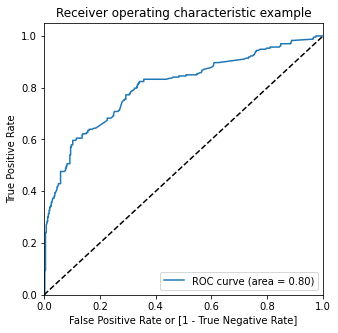

In [58]:
draw_roc(y_train_pred_final.Survived, y_train_pred_final.Survival_Prob)

In [59]:
y_train_pred_final['predicted'] = y_train_pred_final.Survival_Prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Survived,Survival_Prob,PassengerId,predicted
0,0,0.188940,86,0
1,1,0.168885,889,0
2,0,0.162119,162,0
3,0,0.155996,760,0
4,0,0.464049,409,0


In [60]:
confusion = metrics.confusion_matrix(y_train_pred_final.Survived, y_train_pred_final.predicted )
print(confusion)

[[366  23]
 [125 108]]


In [61]:
print(metrics.accuracy_score(y_train_pred_final.Survived, y_train_pred_final.predicted))

0.7620578778135049


In [62]:
#X_test_sm = sm.add_constant(X_test[col])
y_test_pred = res.predict(X_test[col])
y_test_pred[:10]

639    3.476556e-05
147    5.376652e-02
278    7.118970e-03
484    9.077078e-05
770    1.222619e-04
874    1.947160e-04
157    1.978118e-05
660    1.099201e-07
792    1.369655e-04
533    7.742841e-05
dtype: float64

In [63]:
y_test_pred = y_test_pred.values.reshape(-1)
y_test_pred[:10]

array([3.47655615e-05, 5.37665185e-02, 7.11897013e-03, 9.07707803e-05,
       1.22261892e-04, 1.94716037e-04, 1.97811786e-05, 1.09920142e-07,
       1.36965481e-04, 7.74284083e-05])

In [64]:
y_test_pred_final = pd.DataFrame({'Survived':y_test.values, 'Survival_Prob':y_test_pred})
y_test_pred_final['PassengerId'] = y_test.index
y_test_pred_final.head()


,Survived,Survival_Prob,PassengerId
0,0,0.000035,639
1,0,0.053767,147
2,0,0.007119,278
3,1,0.000091,484
4,0,0.000122,770


In [65]:
y_test_pred_final['predicted'] = y_test_pred_final.Survival_Prob.map(lambda x: 1 if x > 0.3 else 0)

# Let's see the head
y_test_pred_final.head()

,Survived,Survival_Prob,PassengerId,predicted
0,0,0.000035,639,0
1,0,0.053767,147,0
2,0,0.007119,278,0
3,1,0.000091,484,0
4,0,0.000122,770,0


In [66]:
confusion = metrics.confusion_matrix(y_test_pred_final.Survived, y_test_pred_final.predicted )
print(confusion)

[[159   1]
 [105   2]]


In [67]:
print(metrics.accuracy_score(y_test_pred_final.Survived, y_test_pred_final.predicted))

0.602996254681648


In [68]:
y_test_pred_final.predicted.value_counts()

0    264
1      3
Name: predicted, dtype: int64

-----------------------


------------------


In [69]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
from sklearn.feature_selection import RFE
rfe = RFE(logreg, 9)             # running RFE with 5 variables as output
rfe = rfe.fit(X_train, y_train)

In [70]:
col = X_train.columns[rfe.support_]
features = ["Pclass_2", "male", "SibSp", "Parch"]

In [71]:
#model = svc.fit(X_train[col], y_train)
#y_pred = model.predict(X_test[col])

In [72]:
#from sklearn.metrics import accuracy_score, confusion_matrix
#accuracy = accuracy_score(y_pred, y_test)
#print(accuracy)

#confusion_matrix(y_pred, y_test)

### SVM 

In [73]:
from sklearn.svm import SVC

svc = SVC(C= 1.0, gamma= 0.5)

model = svc.fit(X_train[col], y_train)
y_pred = model.predict(X_test[col])



In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

confusion_matrix(y_pred, y_test)

0.602996254681648


array([[160, 106],
       [  0,   1]])

### Random Forest

In [75]:
from sklearn.model_selection import GridSearchCV

In [76]:
# Create the parameter grid based on the results of random search 
params = {
    'n_estimators': [1, 5, 10, 50, 100, 200],
    'max_depth': [1, 2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'criterion': ["gini", "entropy"]
}



In [77]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()


grid_search = GridSearchCV(estimator=rf, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

grid_search.fit(X_train[col], y_train)



grid_search.best_estimator_
#y_pred = model.predict(X_test[col])

Fitting 4 folds for each of 300 candidates, totalling 1200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 292 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:   42.9s
[Parallel(n_jobs=-1)]: Done 1200 out of 1200 | elapsed:  1.1min finished


RandomForestClassifier(max_depth=5, n_estimators=200)

In [78]:
rf_best = grid_search.best_estimator_
model = rf_best.fit(X_train[col], y_train)
y_pred = model.predict(X_test[col])

In [79]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

confusion_matrix(y_pred, y_test)

0.8052434456928839


array([[153,  45],
       [  7,  62]])

### GRAD boost

In [80]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [81]:
params = {
    'n_estimators': [1, 5, 10, 50, 100, 200],
    'learning_rate': [1, 2, 3, 5, 10],
    'max_depth': [1, 2, 5, 10, 20],
    'max_features': ["auto"]
    
}


In [82]:
gb = GradientBoostingClassifier(random_state=0)

In [83]:
grid_search = GridSearchCV(estimator=gb, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

grid_search.fit(X_train, y_train)
grid_search.best_estimator_

Fitting 4 folds for each of 150 candidates, totalling 600 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 408 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:   35.0s finished


GradientBoostingClassifier(learning_rate=1, max_depth=2, max_features='auto',
                           n_estimators=200, random_state=0)

In [84]:
gb_best = grid_search.best_estimator_
clf = gb_best.fit(X_train, y_train)

In [85]:
clf.score(X_test, y_test)

0.7752808988764045

### XG Boost

In [86]:
import xgboost as xgb
from sklearn import metrics

xgclf = xgb.XGBClassifier()
xgb_model = xgb.XGBClassifier()

In [87]:
# 1st-Run for best hyperparameters
parameters = {'learning_rate': [0.1, 0.2, 0.3, 0.4],
              'max_depth': [2, 4, 6, 8],
              'min_child_weight': [3, 7, 11, 19],
              'n_estimators': [50, 100, 150, 200]}

scorer = metrics.make_scorer(metrics.roc_auc_score,
                             greater_is_better=True,
                             needs_proba=True,
                             needs_threshold=False)

clf_xgb = GridSearchCV(estimator=xgb_model,
                                       param_grid=parameters,
                                       n_jobs=-1,
                                       cv=3,
                                       scoring=scorer,
                                       verbose = 1,
                                       refit=True)

clf_xgb.fit(X_train[features], y_train)

Fitting 3 folds for each of 256 candidates, totalling 768 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed: 20.9min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed: 47.4min


[05:23:20] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


[Parallel(n_jobs=-1)]: Done 768 out of 768 | elapsed: 83.5min finished


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, gamma=None,
                                     gpu_id=None, importance_type='gain',
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs...
                                     num_parallel_tree=None, random_state=None,
                                     reg_alpha=None, reg_lambda=None,
                                     scale_pos_weight=None, subsample=None,
                                     tree_method=None, va

In [88]:
print(clf_xgb.best_params_)
print(clf_xgb.best_score_)
print(clf_xgb.best_estimator_)

{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 50}
0.817267280192146
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=4,
              min_child_weight=3, missing=nan, monotone_constraints='()',
              n_estimators=50, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)


In [89]:
clf_xgb_best = grid_search.best_estimator_
model = clf_xgb_best.fit(X_train[features], y_train)
y_pred = model.predict(X_test[features]) 

In [90]:
accuracy = accuracy_score(y_pred, y_test)
print(accuracy)

confusion_matrix(y_pred, y_test)

0.8089887640449438


array([[140,  31],
       [ 20,  76]])